In [ ]:
# Install libraries
!pip install -q accelerate transformers ftfy bitsandbytes peft
!pip install -q torchao==0.16.0
# Clone diffusers for DreamBooth training script
!git clone https://github.com/huggingface/diffusers.git
!pip install -q git+https://github.com/huggingface/diffusers.git
!pip install -q -r /content/diffusers/examples/dreambooth/requirements.txt

from accelerate.utils import write_basic_config
write_basic_config()
print("✓ Done")

fatal: destination path 'diffusers' already exists and is not an empty directory.
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
Configuration already exists at /root/.cache/huggingface/accelerate/default_config.yaml, will not override. Run `accelerate config` manually or pass a different `save_location`.
✓ Done


In [ ]:
import os
import shutil
import json
!pip install --upgrade peft
import pandas as pd
import zipfile
import diffusers

  Using cached peft-0.19.1-py3-none-any.whl.metadata (15 kB)
Using cached peft-0.19.1-py3-none-any.whl (680 kB)
  Attempting uninstall: peft
    Found existing installation: peft 0.7.0
    Uninstalling peft-0.7.0:
      Successfully uninstalled peft-0.7.0


In [ ]:
from google.colab import drive
drive.mount("/content/drive", force_remount=True)

Mounted at /content/drive


In [ ]:
zip_path     = "/content/drive/MyDrive/CelebAMask-HQ.zip"
extract_path = "/content/celeba_data/"

if not os.path.exists(extract_path):
    print("Extracting to local storage...")
    with zipfile.ZipFile(zip_path, "r") as z:
        z.extractall(extract_path)
    print("Extraction complete.")
else:
    print("Dataset already extracted — skipping.")

Dataset already extracted — skipping.


In [ ]:
print(os.listdir("/content/celeba_data/CelebAMask-HQ/"))

['CelebA-HQ-img', 'CelebAMask-HQ-mask-anno', 'CelebA-HQ-to-CelebA-mapping.txt', 'CelebAMask-HQ-pose-anno.txt', '.DS_Store', 'CelebAMask-HQ-attribute-anno.txt', 'README.txt']


In [ ]:
# Load the HQ mapping
mapping_df = pd.read_csv(
    "/content/celeba_data/CelebAMask-HQ/CelebA-HQ-to-CelebA-mapping.txt",
    sep=r"\s+", header=0
)

# Load original identity labels
identity_df = pd.read_csv(
    "/content/drive/MyDrive/identity_CelebA.txt",
    sep=r"\s+", header=None, names=["orig_file", "person_id"]
)

# Merge
merged_df = pd.merge(mapping_df, identity_df, on="orig_file")
merged_df["hq_filename"] = merged_df["idx"].apply(lambda x: f"{x}.jpg")
final_mapping = merged_df[["hq_filename", "person_id"]]
print(final_mapping.head())

  hq_filename  person_id
0       0.jpg       7423
1       1.jpg       7319
2       2.jpg       6632
3       3.jpg       3338
4       4.jpg       9178


In [ ]:
# Count images per person
id_counts  = final_mapping["person_id"].value_counts()
candidates = id_counts[id_counts >= 5].index.tolist()
print(f"Total candidates: {len(candidates)}")

selected_ids = candidates[:3]
print(f"Selected Person IDs: {selected_ids}")

Total candidates: 2398
Selected Person IDs: [861, 5247, 5884]


In [ ]:
# ── Prepare 1-shot training folder  ───────────────────
base_img_path = "/content/celeba_data/CelebAMask-HQ/CelebA-HQ-img/"
target_person = selected_ids[0]

# DreamBooth instance folder
instance_dir = f"/content/dreambooth_instance_{target_person}"
os.makedirs(instance_dir, exist_ok=True)

person_images = final_mapping[
    final_mapping["person_id"] == target_person
]["hq_filename"].tolist()

# Copy 1 image for 1-shot
dst = os.path.join(instance_dir, "img_0.jpg")
shutil.copy(os.path.join(base_img_path, person_images[0]), dst)

print(f"Instance folder: {os.listdir(instance_dir)}")
print(f"Person ID      : {target_person}")

# DreamBooth class folder — prior preservation images

class_dir = f"/content/dreambooth_class_{target_person}"
os.makedirs(class_dir, exist_ok=True)

# Use 50 random CelebA images as class images
import random
all_imgs    = [f for f in os.listdir(base_img_path) if f.endswith(".jpg")]
class_imgs  = [f for f in all_imgs if f not in person_images]
class_sample = random.sample(class_imgs, 50)

for i, fn in enumerate(class_sample):
    shutil.copy(
        os.path.join(base_img_path, fn),
        os.path.join(class_dir, f"class_{i}.jpg")
    )
print(f"Class folder   : {len(os.listdir(class_dir))} images (prior preservation)")

Instance folder: ['img_0.jpg']
Person ID      : 861
Class folder   : 50 images (prior preservation)


In [ ]:
%cd /content/diffusers/examples/dreambooth

/content/diffusers/examples/dreambooth


In [ ]:
# ── DreamBooth Training ─────────────────────────────────────────────
%cd /content/diffusers/examples/dreambooth

import subprocess

OUTPUT_DIR      = f"/content/dreambooth_output_{target_person}"
INSTANCE_PROMPT = "a photo of sks_person face"
CLASS_PROMPT    = "a photo of a person face"

cmd = [
    "accelerate", "launch", "train_dreambooth_lora.py",
    "--pretrained_model_name_or_path=runwayml/stable-diffusion-v1-5",
    f"--instance_data_dir=/content/dreambooth_instance_{target_person}",
    f"--class_data_dir=/content/dreambooth_class_{target_person}",
    f"--output_dir={OUTPUT_DIR}",
    f"--instance_prompt={INSTANCE_PROMPT}",
    f"--class_prompt={CLASS_PROMPT}",
    "--resolution=256",
    "--train_batch_size=1",
    "--gradient_accumulation_steps=1",
    "--learning_rate=1e-4",
    "--lr_scheduler=constant",
    "--lr_warmup_steps=0",
    "--num_class_images=50",
    "--max_train_steps=500",
    "--with_prior_preservation",
    "--prior_loss_weight=1.0",
    "--seed=42",
    "--mixed_precision=fp16",
    "--gradient_checkpointing",
    "--use_8bit_adam",
]

result = subprocess.run(cmd, check=True)


/content/diffusers/examples/dreambooth


In [ ]:
# ── Load fine-tuned DreamBooth model and generate ───────────────────

from diffusers import StableDiffusionPipeline
import torch

# Load base model
pipe = StableDiffusionPipeline.from_pretrained(
    "runwayml/stable-diffusion-v1-5",  # same base model used in training
    torch_dtype=torch.float16,
    safety_checker=None,
    requires_safety_checker=False
).to("cuda")

#  load DreamBooth-LoRA weights on top
pipe.load_lora_weights(OUTPUT_DIR)

print("✓ DreamBooth-LoRA loaded successfully")
print(os.listdir(OUTPUT_DIR))  # verify what was saved

fixed_prompts = [
    "A high-quality studio headshot of sks_person face, facing the camera, neutral expression, plain grey background, soft even lighting, 35mm lens, realistic skin texture.",
    "A high-quality studio portrait of sks_person face, upper body, looking slightly to the left, neutral expression, plain grey background, soft directional lighting from the right.",
    "A high-quality portrait of sks_person face, facing the camera, big natural smile, teeth visible, blurred indoor background, warm soft lighting.",
    "A cinematic close-up of sks_person face, neutral expression, dark background, strong side lighting creating shadows on half of the face, high contrast, realistic skin texture.",
    "A realistic outdoor portrait of sks_person face, upper body, standing in a city street during the day, soft natural daylight, shallow depth of field, background slightly blurred.",
    "A realistic outdoor portrait of sks_person face, upper body, standing in a city at sunset, warm orange light on the face, soft bokeh lights in the background.",
    "A realistic portrait of sks_person face, sitting indoors near a window, soft daylight from the side, bookshelf in the background, natural colours, medium shot.",
    "A realistic portrait of sks_person face, facing the camera, wearing simple glasses, neutral expression, plain light background, soft studio lighting.",
    "A realistic half-body photo of sks_person face, standing, facing the camera, neutral expression, simple indoor background, soft even lighting.",
    "A realistic portrait of sks_person face, varied pose and expression, random indoor or outdoor background, natural lighting, photographic style."
]

# Generate 300 images — 30 per prompt
results_dir = f"/content/generated_dreambooth_{target_person}"
os.makedirs(results_dir, exist_ok=True)

image_count = 0
for prompt in fixed_prompts:
    for i in range(30):
        image = pipe(
            prompt,
            num_inference_steps=30,
            guidance_scale=7.5
        ).images[0]
        image.save(f"{results_dir}/img_{image_count}.png")
        image_count += 1

print(f"Generated {image_count} images.")

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
No LoRA keys associated to CLIPTextModel found with the prefix='text_encoder'. This is safe to ignore if LoRA state dict didn't originally have any CLIPTextModel related params. You can also try specifying `prefix=None` to resolve the warning. Otherwise, open an issue if you think it's unexpected: https://github.com/huggingface/diffusers/issues/new


✓ DreamBooth-LoRA loaded successfully
['checkpoint-500', 'pytorch_lora_weights.safetensors', 'logs']


...

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

Generated 300 images.


In [ ]:
# ── FID  ─────────────────────────────────────────
!pip install -q clean-fid
from cleanfid import fid
import random

real_dir = f"/content/real_test_{target_person}"
if os.path.isfile(real_dir):
    os.remove(real_dir)
os.makedirs(real_dir, exist_ok=True)

# Copy all identity images
person_imgs = final_mapping[
    final_mapping["person_id"] == target_person
]["hq_filename"].tolist()
for fn in person_imgs:
    shutil.copy(os.path.join(base_img_path, fn), real_dir)

# Pad with random faces to reach 300
if len(person_imgs) < 300:
    all_imgs = [f for f in os.listdir(base_img_path) if f.endswith(".jpg")]
    all_imgs = [f for f in all_imgs if f not in person_imgs]
    extras   = random.sample(all_imgs, 300 - len(person_imgs))
    for fn in extras:
        shutil.copy(os.path.join(base_img_path, fn), real_dir)

print(f"Real images: {len(os.listdir(real_dir))}")

fid_score = fid.compute_fid(results_dir, real_dir)
print(f"FID → {fid_score:.2f}")

Real images: 300


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 12 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


compute FID between two folders
Found 300 images in the folder /content/generated_dreambooth_861


FID generated_dreambooth_861 :   0%|          | 0/10 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 12 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
FID generated_dreambooth_861 : 100%|██████████| 10/10 [00:22<00:00,  2.26s/it]


Found 300 images in the folder /content/real_test_861


FID real_test_861 : 100%|██████████| 10/10 [00:23<00:00,  2.40s/it]


FID → 162.83


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 170.7/170.7 kB 9.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 9.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 212.0/212.0 kB 11.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.4/70.4 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 35.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.5/51.5 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 44.7 MB/s eta 0:00:00
26-05-10 20:31:47 - Directory /root/.deepface has been created
26-05-10 20:31:47 - Directory /root/.deepface/weights has been created
26-05-10 20:31:49 - 🔗 arcface_weights.h5 will be downloaded from https://github.com/serengil/deepface_models/releases/download/v1.0/arcface_weights.h5 to /root/.deepface/weights/arcface_weights.h5...


Downloading...
From: https://github.com/serengil/deepface_models/releases/download/v1.0/arcface_weights.h5
To: /root/.deepface/weights/arcface_weights.h5
100%|██████████| 137M/137M [00:04<00:00, 34.0MB/s]


Reference image: img_0.jpg


FRS: 100%|██████████| 300/300 [03:14<00:00,  1.54it/s]


FRS → mean=0.2690  std=0.1827


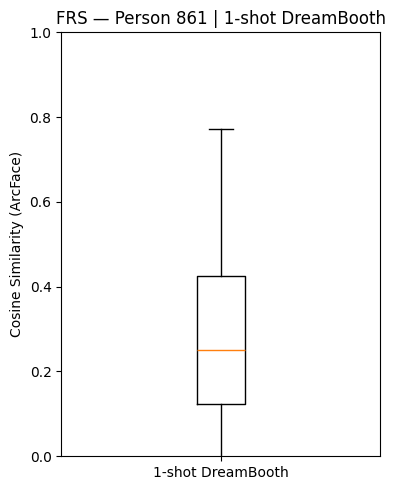

In [ ]:
# ── FRS  ────────────────
!pip install deepface
from deepface import DeepFace
from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt

def get_embedding(img_path):
    try:
        result = DeepFace.represent(
            img_path, model_name="ArcFace", enforce_detection=False
        )
        return np.array(result[0]["embedding"])
    except:
        return None

def cosine_sim(a, b):
    a = a / (np.linalg.norm(a) + 1e-8)
    b = b / (np.linalg.norm(b) + 1e-8)
    return float(np.dot(a, b))

# Reference embedding — same 1 training image
ref_files = [f for f in os.listdir(instance_dir)
             if f.lower().endswith((".jpg", ".png"))]
ref_emb   = get_embedding(os.path.join(instance_dir, ref_files[0]))
print(f"Reference image: {ref_files[0]}")

sims = []
for fn in tqdm(os.listdir(results_dir), desc="FRS"):
    if fn.lower().endswith(".png"):
        emb = get_embedding(os.path.join(results_dir, fn))
        if emb is not None:
            sims.append(cosine_sim(emb, ref_emb))

print(f"FRS → mean={np.mean(sims):.4f}  std={np.std(sims):.4f}")

# Boxplot
plt.figure(figsize=(4, 5))
plt.boxplot(sims, labels=["1-shot DreamBooth"])
plt.title(f"FRS — Person {target_person} | 1-shot DreamBooth")
plt.ylabel("Cosine Similarity (ArcFace)")
plt.ylim(0, 1)
plt.tight_layout()
plt.savefig("/content/frs_boxplot_dreambooth.png", dpi=150)
plt.show()

In [ ]:
# ── LPIPS Diversity  ───────────────────────────────────
!pip install -q lpips
import lpips
import torch
import numpy as np
from PIL import Image
from torchvision import transforms
from tqdm import tqdm

loss_fn = lpips.LPIPS(net="alex").cuda()

def load_tensor(img_path, size=256):
    img = Image.open(img_path).convert("RGB").resize((size, size))
    t   = transforms.ToTensor()(img) * 2 - 1
    return t.unsqueeze(0).cuda()

gen_files = [os.path.join(results_dir, f)
             for f in os.listdir(results_dir)
             if f.lower().endswith(".png")]

rng   = np.random.default_rng(42)
idxs  = rng.choice(len(gen_files), size=(200, 2), replace=True)
dists = []
for i, j in tqdm(idxs, desc="LPIPS pairs"):
    if i == j:
        continue
    with torch.no_grad():
        d = loss_fn(load_tensor(gen_files[i]), load_tensor(gen_files[j]))
    dists.append(d.item())

print(f"LPIPS Diversity → {np.mean(dists):.4f}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.8/53.8 kB 4.8 MB/s eta 0:00:00
Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]
Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to /root/.cache/torch/hub/checkpoints/alexnet-owt-7be5be79.pth


100%|██████████| 233M/233M [00:04<00:00, 49.6MB/s]


Loading model from: /usr/local/lib/python3.12/dist-packages/lpips/weights/v0.1/alex.pth


LPIPS pairs: 100%|██████████| 200/200 [00:15<00:00, 13.15it/s]

LPIPS Diversity → 0.5074


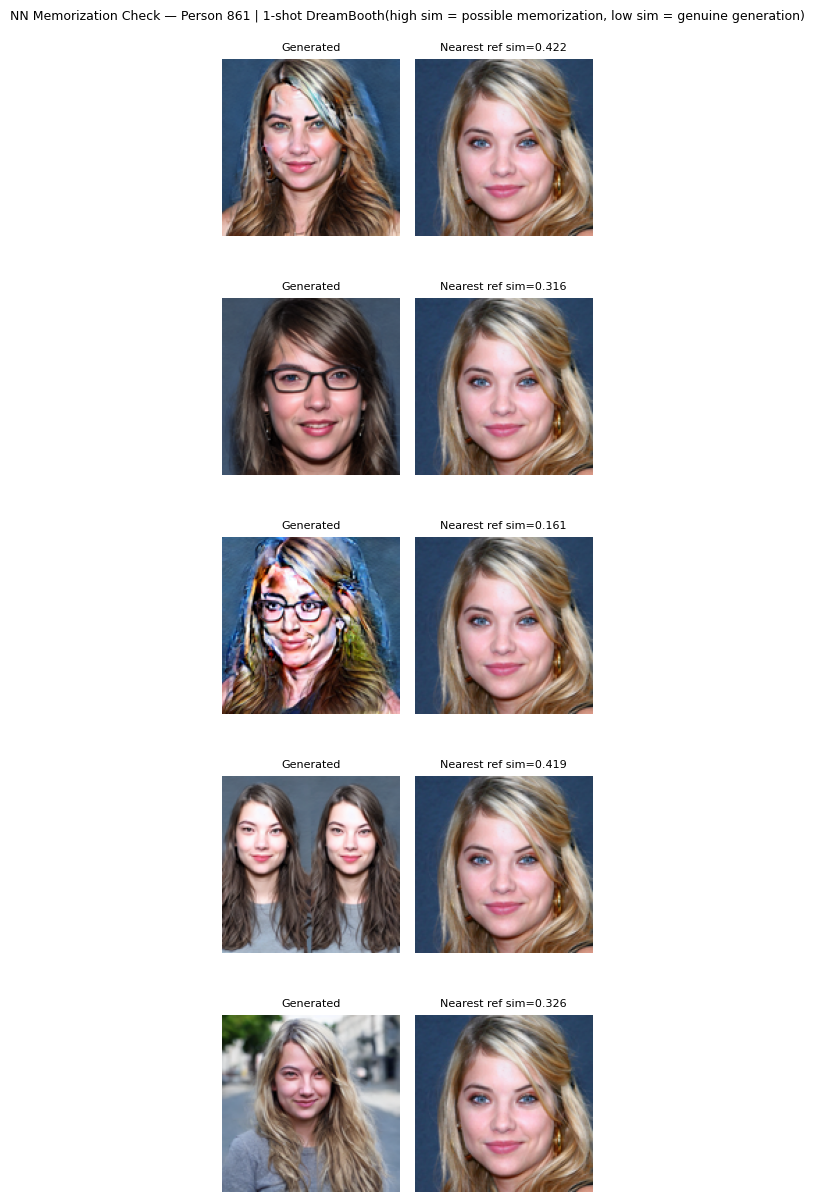

In [ ]:
# ── Nearest-Neighbour Memorization Check  ─────────────
import random
from PIL import Image
import matplotlib.pyplot as plt

ref_files_full = [os.path.join(instance_dir, f)
                  for f in os.listdir(instance_dir)
                  if f.lower().endswith((".jpg", ".png"))]
ref_embs = [(fp, get_embedding(fp)) for fp in ref_files_full]
ref_embs = [(fp, e) for fp, e in ref_embs if e is not None]

# Sample 5 random generated images
gen_files = [os.path.join(results_dir, f)
             for f in os.listdir(results_dir)
             if f.lower().endswith(".png")]
sampled = random.sample(gen_files, min(5, len(gen_files)))

fig, axes = plt.subplots(len(sampled), 2, figsize=(4, 2.5 * len(sampled)))

for row, gen_path in enumerate(sampled):
    gen_emb = get_embedding(gen_path)
    if gen_emb is None:
        continue
    similarities = [(fp, float(cosine_sim(gen_emb, e))) for fp, e in ref_embs]
    nn_path, nn_sim = max(similarities, key=lambda x: x[1])

    axes[row][0].imshow(Image.open(gen_path).resize((128, 128)))
    axes[row][0].set_title("Generated", fontsize=8)
    axes[row][0].axis("off")

    axes[row][1].imshow(Image.open(nn_path).resize((128, 128)))
    axes[row][1].set_title(f"Nearest ref sim={nn_sim:.3f}", fontsize=8)
    axes[row][1].axis("off")

plt.suptitle(
    f"NN Memorization Check — Person {target_person} | 1-shot DreamBooth"
    f"(high sim = possible memorization, low sim = genuine generation)",
    fontsize=9
)
plt.tight_layout()
plt.savefig("/content/Memorization_check_dreambooth.png", dpi=150)
plt.show()